In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [2]:
entries_df = pd.read_json("../data/large_files/ruland-emlap.json")

In [6]:
emlap_metadata = pd.read_csv("../data/emlap_metadata.csv", sep=";")
emlap_metadata.head(5)

,working_title,No.,is_done,is_noscemus,if_noscemus_id,"#if is_noscemus = True, don't transcribe",AUTHORSHIP,is_one_author,#if more than 1 author skip section and choose compendium below,is_author_known,...,link,source_of_file,origin_of_copy,REFERENCES,catalogue_reference,secondary_references,general_comments,OTHER,filename,Unnamed: 64
0,"Augurello, Chrysopoeia",100001,True,True,713324.0,NaN,NaN,True,NaN,True,...,https://wiki.uibk.ac.at/noscemus/Chrysopoeia,Noscemus,Unknown,NaN,Noscemus Wiki,Soranzo 2019,The 1518 Basel version is also in Noscemus,NaN,"Augurello,_Giovanni_Aurelio_-_Chrysopoeia__Ven...",NaN
1,"Pseudo-Lull, Secretis",100002,True,False,NaN,NaN,NaN,True,NaN,True,...,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MBS,NaN,Hirsch 1950,NaN,"There is a prior, 1514 edition of De secretis ...",NaN,Pseudo-Lull1518_De_secretis_naturae_MDZ.pdf,NaN
2,"Pantheus, Ars Transmutatione",100003,True,False,NaN,NaN,NaN,True,NaN,True,...,NaN,GB,BL,NaN,NaN,NaN,This book was first published in 1518 with an ...,NaN,Pantheus1518_Ars_Transmutationis_Metallicae_BL...,NaN
3,"Pantheus, Commentarium",100004,True,False,NaN,NaN,NaN,True,NaN,True,...,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MSB,NaN,NaN,NaN,This 1519 book is catalogued wrongly by many l...,NaN,Pantheus1519_Commentarium_Transmutationis_Meta...,NaN
4,"Pantheus, Voarchadumia",100005,True,False,NaN,NaN,NaN,True,NaN,True,...,NaN,ONB,ONB,NaN,NaN,NaN,Dedicated to Leonellus Marquis of Estense,NaN,Pantheus1530_Voarchadumia_ONB.pdf,NaN


In [51]:
emlap_metadata["labeldate"] = emlap_metadata.apply(lambda row: row["working_title"] + " ({})".format(str(row["date_publication"])), axis=1)

In [58]:
emlap_metadata.sort_values("date_publication", ascending=True, inplace=True)

In [59]:
emlap_id_label_dict = dict(zip(emlap_metadata["No."], emlap_metadata["labeldate"]))

In [82]:
def make_plot_bar(entry):
    # Get instances IDs for the entry
    instances_ids = entries_df[entries_df["Lemma"] == entry]["instances_ids"].tolist()[0]
    counter = Counter(instances_ids)

    # Extract the keys (labels) and their corresponding counts (frequencies)
    emlap_metadata_instances = emlap_metadata.copy()
    emlap_metadata_instances["Frequency"] = (
        emlap_metadata_instances["No."].map(counter).fillna(0).astype(int)
    )

    # Add bidecade labels to the DataFrame
    def get_bidecade_label(year):
        start = (year // 20) * 20  # Determine the starting year of the bidecade
        end = start + 19  # Determine the ending year of the bidecade
        return f"{start}-{end}"

    emlap_metadata_instances["Bidecade"] = emlap_metadata_instances["date_publication"].apply(
        lambda year: get_bidecade_label(year) if not np.isnan(year) else None
    )

    # Group by Bidecade and sum frequencies
    emlap_instances_grouped = (
        emlap_metadata_instances.groupby("Bidecade", dropna=True)["Frequency"]
        .sum()
        .reset_index()
    )

    # Sort bidecade intervals numerically
    emlap_instances_grouped = emlap_instances_grouped.sort_values(
        by="Bidecade",
        key=lambda col: col.str.extract(r"(\d+)")[0].astype(int),  # Fix incorrect sorting issue
    )

    # Create the bar plot
    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(15, 20), dpi=300)

    # Plot frequencies by bidecades
    ax1.bar(
        emlap_instances_grouped["Bidecade"],
        emlap_instances_grouped["Frequency"],
        color="blue"
    )
    # Set labels and title for the second plot
    ax1.set_xlabel("Bidecades")
    ax1.set_ylabel("Frequency")
    ax1.set_title(f"Bidecade Distribution of '{entry}' Instances")
    # Set x-ticks to match the bidecades
    ax1.set_xticks(range(len(emlap_instances_grouped["Bidecade"])))  # Fixed number of tick positions
    ax1.set_xticklabels(emlap_instances_grouped["Bidecade"], rotation=90)  # Rotate bidecade labels

    # Plot frequencies by works
    ax2.bar(
        emlap_metadata_instances["labeldate"],
        emlap_metadata_instances["Frequency"],
        color="blue"
    )
    # Set labels and title for the first plot
    ax2.set_xlabel("Works")
    ax2.set_ylabel("Frequency")
    ax2.set_title(f"Total instances of '{entry}' in EMLAP")
    ax2.set_xticks(emlap_metadata_instances["labeldate"])  # Set x-ticks
    ax2.set_xticklabels(emlap_metadata_instances["labeldate"], rotation=90)  # Rotate labels
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

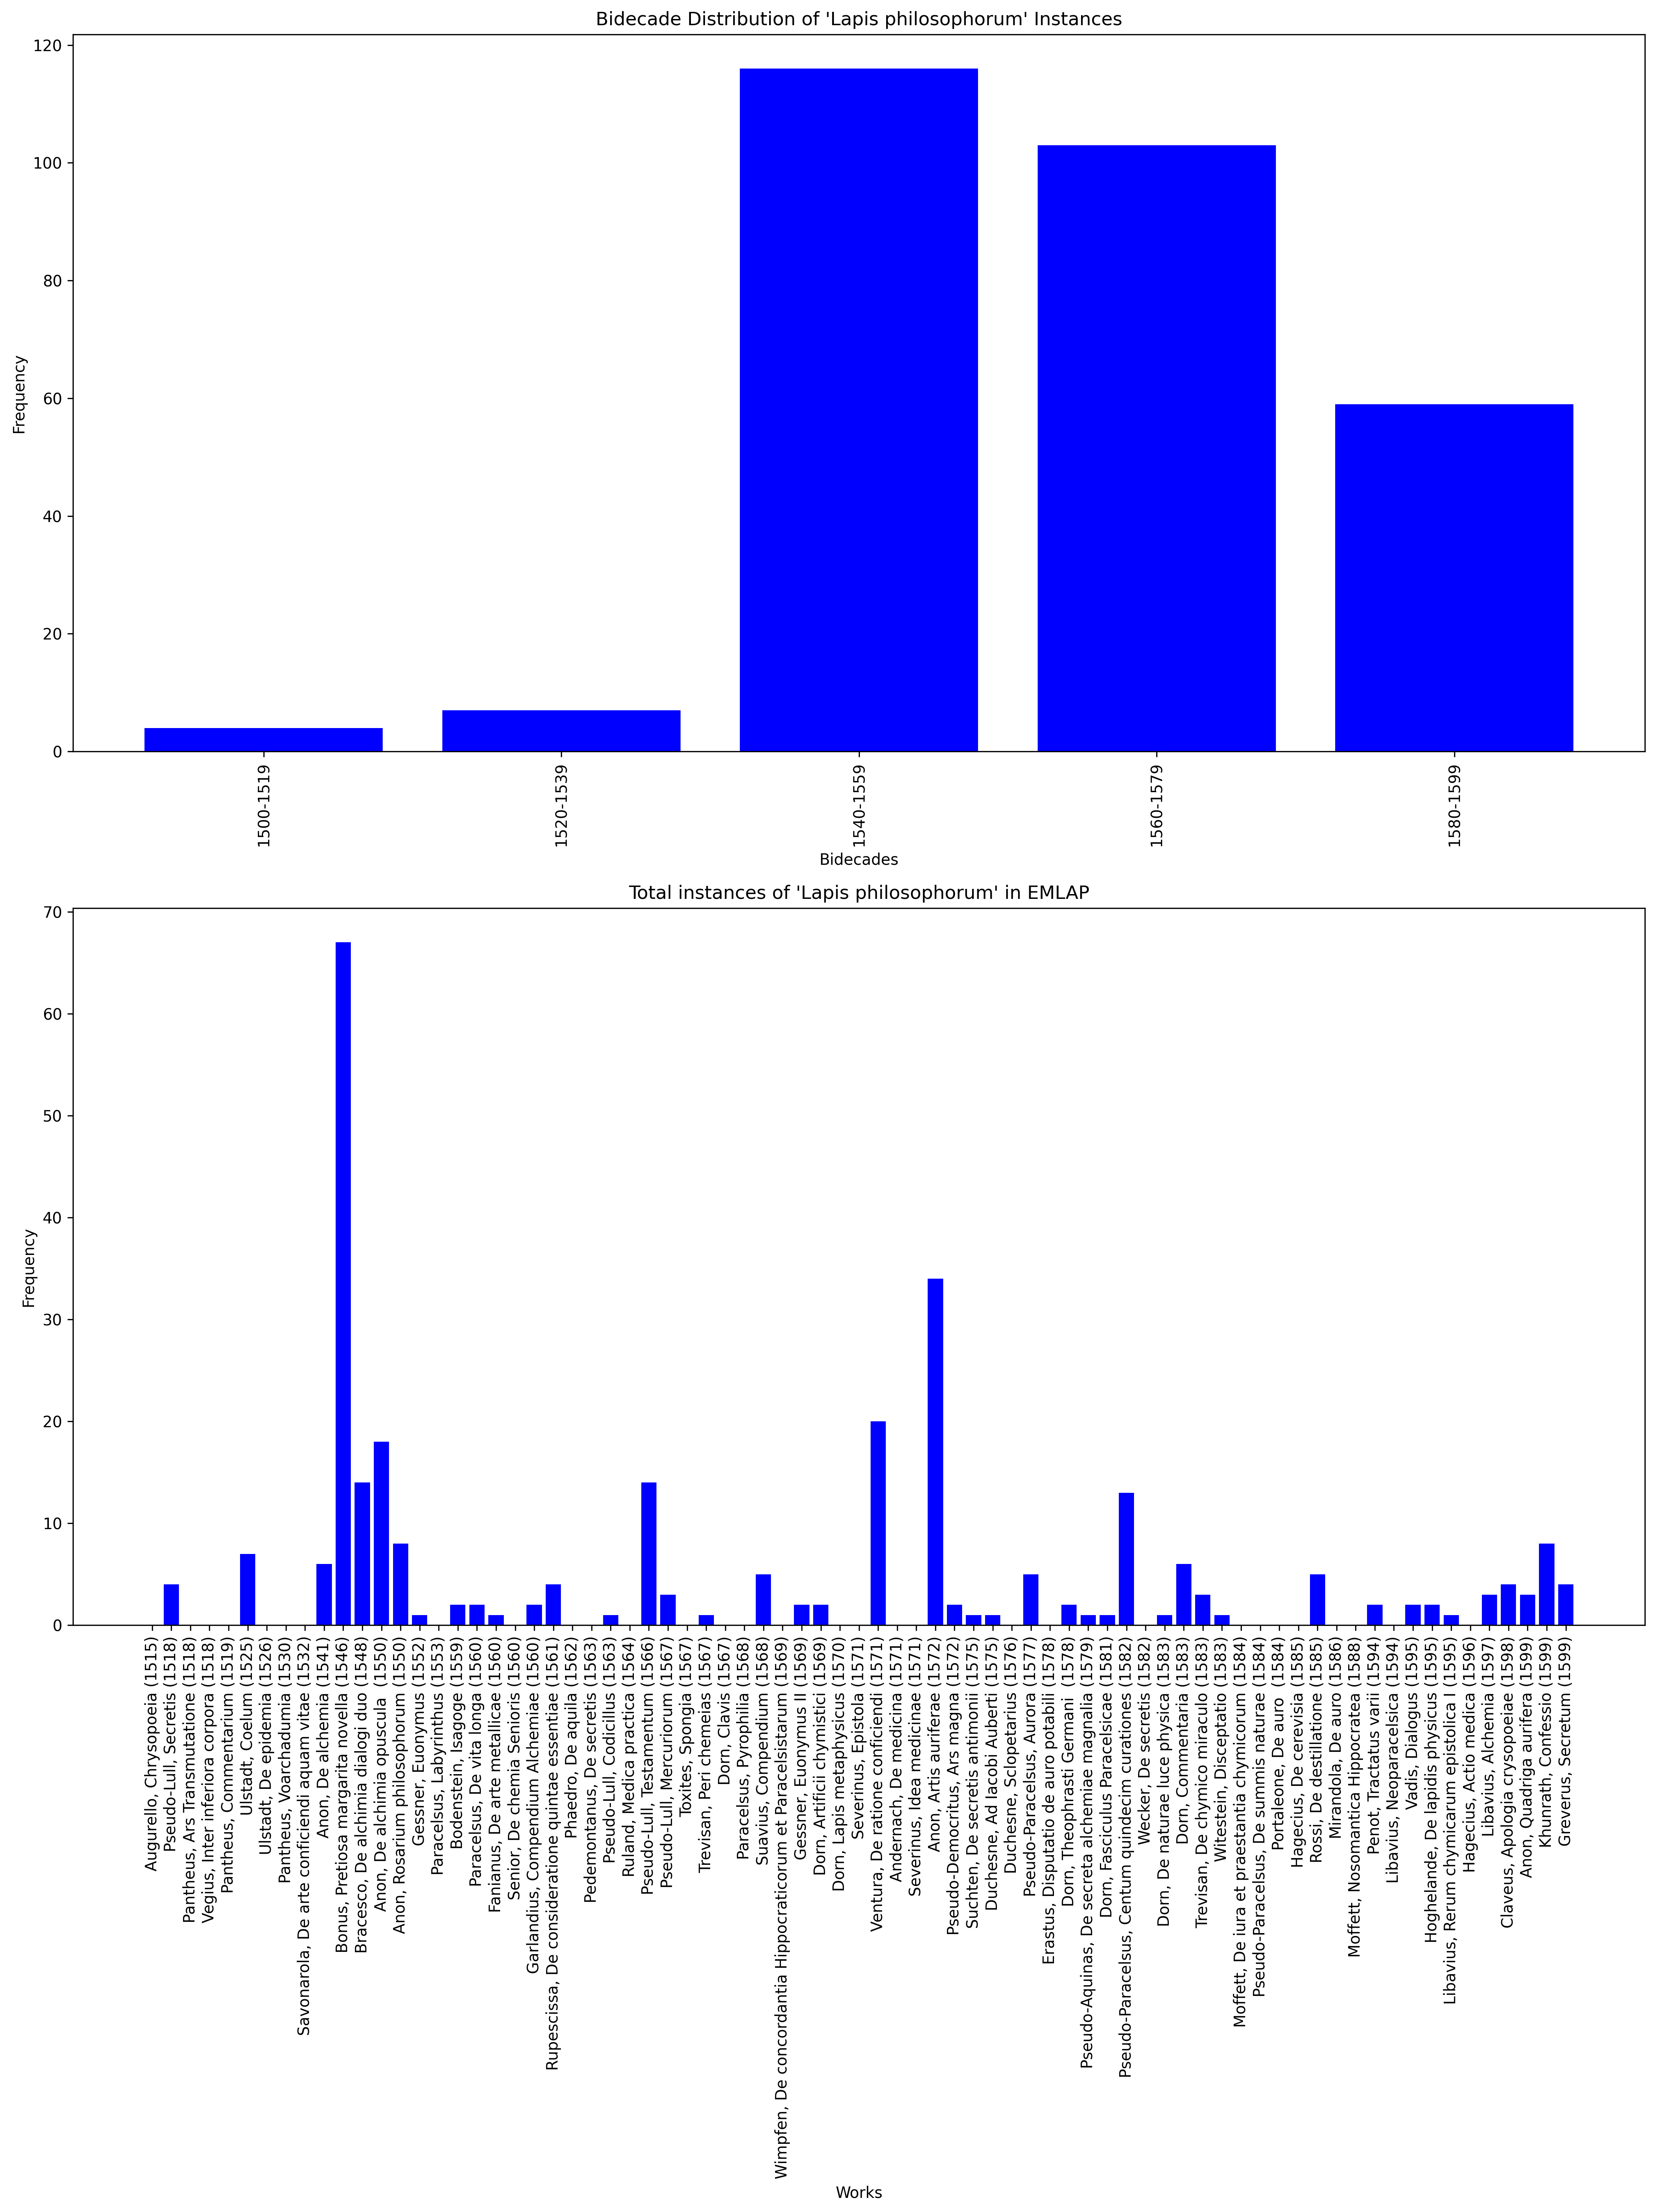

In [83]:
entry = "Lapis philosophorum"
make_plot_bar(entry)